# 🌋 Balıkesir Jeotermal Gradyan Alanı — Gerçek IHFC 2024 Verisiyle PINNs
### ICAME'26 Hazırlık Çalışması | 2D Coğrafi Model (Lon, Lat) → Jeotermal Gradyan

---

## 📌 Çalışmanın Amacı
Balıkesir ili ve çevresindeki **jeotermal gradyan dağılımını** (°C/km), IHFC 2024 Global Heat Flow Database'inden
elde edilen **62 gerçek ölçüm noktası** kullanarak fizik bilgili sinir ağı (PINN) ile modellemek.

**Fizik:** 2D Harmonik Alan (Laplace) Varsayımı
$$\nabla^2 G(\lambda,\phi) = \kappa \, \nabla^2 G(\lambda,\phi)$$

Daha açık biçimde, gradyan alanının düzgün (pürüzsüz) bir bölgesel arka plan + lokal anomalilerden
oluştuğu varsayılır:

$$\frac{\partial^2 G}{\partial \lambda^2} + \frac{\partial^2 G}{\partial \phi^2} = R(\lambda,\phi)$$

- $G$: jeotermal gradyan (°C/km)
- $\lambda$: boylam (longitude)
- $\phi$: enlem (latitude)
- $R$: kalan (rezidüel) — model bunu minimize etmeye çalışır (pürüzsüzlük cezası)

**Ters Problem:** Modelin pürüzsüzlük/yumuşatma katsayısı $\kappa$ verideki gürültü ile fiziksel
sinyal arasındaki dengeyi öğrenir.

---

## 📥 Veri Kaynağı

| Kaynak | Veri Tipi | Nokta Sayısı |
|--------|-----------|--------------|
| **IHFC GHFDB Release 2024 (v.2026.03)** | Isı akısı + termal gradyan, lat/lon, derinlik | 62 (Balıkesir bölgesi) |
| DOI | `10.5880/fidgeo.2024.014` | — |

Bölge: **lat 38.50–40.38°N, lon 26.15–29.00°E** (Balıkesir ili ve yakın çevresi:
Ayvalık, Edremit, Gönen, Bandırma, Susurluk, Balya, Bigadiç, vb.)

---

> **Not:** Bu notebook **gerçek veri** ile çalışır. `balikesir_2d_final.csv` dosyası
> 62 satır gerçek ölçüm içerir (heat_flow_mWm2, T_grad_Cperkm, lat, lon).


## 🔧 Kurulum & Veri Yükleme

In [1]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'axes.grid': True,
    'grid.alpha': 0.3, 'font.size': 11, 'axes.titlesize': 13,
})
torch.manual_seed(42); np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ─── Gerçek veri yükle ───────────────────────────────────────────────────
DATA_PATH = 'balikesir_2d_final.csv'  # /mnt/user-data/uploads/ içine kopyalanmalı

df = pd.read_csv(DATA_PATH)
print(f"✅ Cihaz: {device}")
print(f"✅ Yüklenen nokta sayısı: {len(df)}")
print(f"✅ Kaynak: IHFC GHFDB Release 2024 (v.2026.03), DOI 10.5880/fidgeo.2024.014")
print()
print(df[['name','lat','lon','heat_flow_mWm2','T_grad_Cperkm']].describe())


✅ Cihaz: cpu
✅ Yüklenen nokta sayısı: 62
✅ Kaynak: IHFC GHFDB Release 2024 (v.2026.03), DOI 10.5880/fidgeo.2024.014

             lat        lon  heat_flow_mWm2  T_grad_Cperkm
count  62.000000  62.000000       62.000000      62.000000
mean   39.520915  27.586424       77.451613      41.521110
std     0.581676   0.802902       31.605642      20.923353
min    38.500000  26.150000       17.000000      13.000000
25%    39.086125  27.027576       51.500000      28.877500
50%    39.591650  27.599950       76.000000      35.850000
75%    40.052950  28.179100       99.000000      50.000000
max    40.378019  29.000000      166.000000     130.470000


In [2]:

# ─── Bölge sınırları ────────────────────────────────────────────────────
lat_min, lat_max = df['lat'].min(), df['lat'].max()
lon_min, lon_max = df['lon'].min(), df['lon'].max()

print(f"Enlem aralığı : {lat_min:.3f} - {lat_max:.3f} °N")
print(f"Boylam aralığı: {lon_min:.3f} - {lon_max:.3f} °E")
print(f"Gradyan aralığı: {df['T_grad_Cperkm'].min():.1f} - {df['T_grad_Cperkm'].max():.1f} °C/km")
print(f"Isı akısı aralığı: {df['heat_flow_mWm2'].min():.1f} - {df['heat_flow_mWm2'].max():.1f} mW/m²")

# En yüksek gradyanlı 10 lokasyon (potansiyel jeotermal anomaliler)
print("\n🔥 En yüksek gradyanlı 10 lokasyon:")
print(df.nlargest(10, 'T_grad_Cperkm')[['name','lat','lon','T_grad_Cperkm','heat_flow_mWm2']].to_string(index=False))


Enlem aralığı : 38.500 - 40.378 °N
Boylam aralığı: 26.150 - 29.000 °E
Gradyan aralığı: 13.0 - 130.5 °C/km
Isı akısı aralığı: 17.0 - 166.0 mW/m²

🔥 En yüksek gradyanlı 10 lokasyon:
     name     lat      lon  T_grad_Cperkm  heat_flow_mWm2
 Denizkoy 38.9900 26.85000     130.470000           110.0
Babadere1 39.6000 26.17000     100.000000           100.0
 Selimiye 39.4730 27.90150      97.647000           166.0
    Gonen 40.1802 27.65590      65.000000           130.0
  K.Belen 38.7500 27.25833      63.393939           104.0
   Seyrek 38.5500 26.91730      62.902500            83.0
       78 39.8333 27.08330      60.000000           126.0
       85 39.5833 26.16670      60.000000           126.0
       87 39.1667 27.33330      60.000000           126.0
       89 39.0833 26.91670      60.000000           126.0


---
## 🗺️ BÖLÜM 1 — Ham Veri Görselleştirme

Balıkesir bölgesindeki 62 ölçüm noktasının coğrafi dağılımı ve gradyan değerleri.


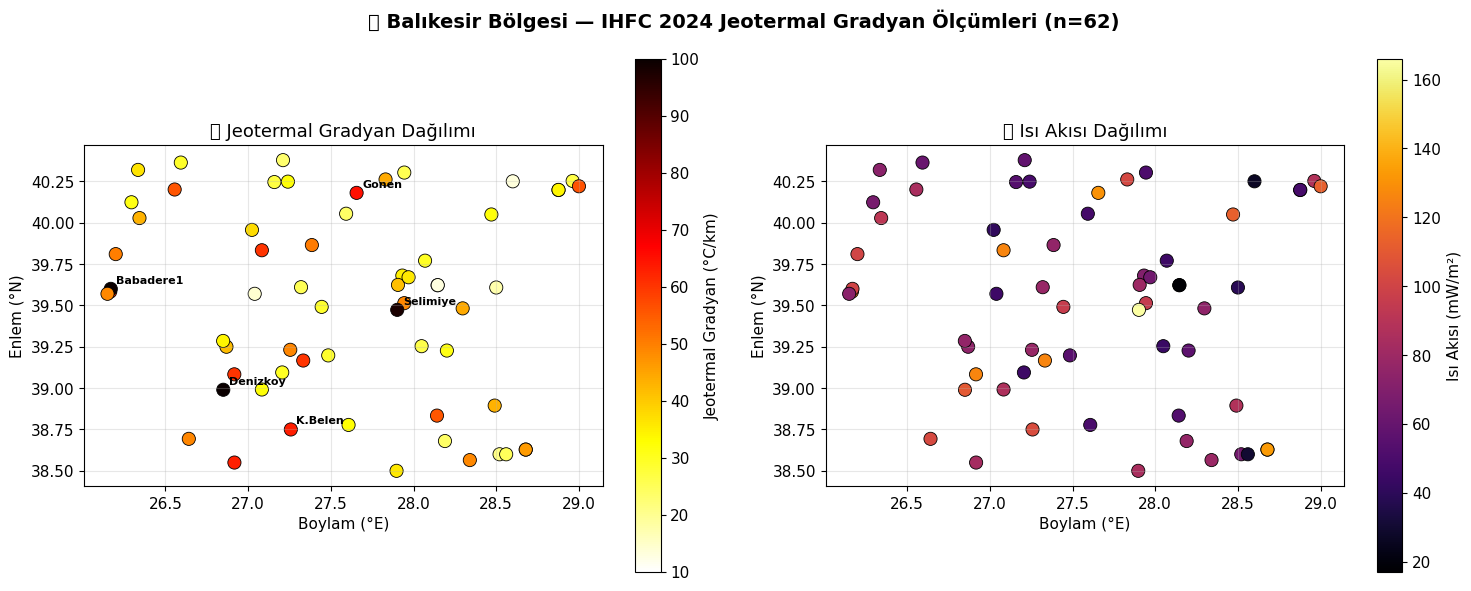

✅ Görsel 1 kaydedildi.


In [3]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🌋 Balıkesir Bölgesi — IHFC 2024 Jeotermal Gradyan Ölçümleri (n=62)',
              fontsize=14, fontweight='bold')

# 1) Gradyan haritası
sc1 = axes[0].scatter(df['lon'], df['lat'], c=df['T_grad_Cperkm'], cmap='hot_r',
                       s=90, edgecolors='black', lw=0.6, vmin=10, vmax=100)
plt.colorbar(sc1, ax=axes[0], label='Jeotermal Gradyan (°C/km)')
# En sıcak 5 nokta etiketle
for _, r in df.nlargest(5, 'T_grad_Cperkm').iterrows():
    axes[0].annotate(r['name'], (r['lon'], r['lat']), fontsize=8,
                      xytext=(4,4), textcoords='offset points', fontweight='bold')
axes[0].set_xlabel('Boylam (°E)'); axes[0].set_ylabel('Enlem (°N)')
axes[0].set_title('📐 Jeotermal Gradyan Dağılımı')
axes[0].set_aspect('equal')

# 2) Isı akısı haritası
sc2 = axes[1].scatter(df['lon'], df['lat'], c=df['heat_flow_mWm2'], cmap='inferno',
                       s=90, edgecolors='black', lw=0.6)
plt.colorbar(sc2, ax=axes[1], label='Isı Akısı (mW/m²)')
axes[1].set_xlabel('Boylam (°E)'); axes[1].set_ylabel('Enlem (°N)')
axes[1].set_title('🔥 Isı Akısı Dağılımı')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('fig1_raw_data_map.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Görsel 1 kaydedildi.")


---
## 🔬 BÖLÜM 2 — PINNs Veri Hazırlığı

**Eğitim noktaları:**
- 62 gerçek ölçüm noktası (lon, lat) → gradyan
- PDE kolokasyon noktaları (bölge içinde rastgele)
- Normalizasyon: lon/lat [0,1] aralığına, gradyan kendi max değerine göre


In [4]:

def prepare_data(df, n_pde=3000, val_frac=0.15, seed=42):
    """2D jeotermal gradyan PINN için veri hazırla."""
    rng = np.random.RandomState(seed)

    lon = df['lon'].values
    lat = df['lat'].values
    grad = df['T_grad_Cperkm'].values

    lon_min, lon_max = lon.min(), lon.max()
    lat_min, lat_max = lat.min(), lat.max()
    grad_scale = grad.max()

    # Normalize
    norm_lon = lambda x: (x - lon_min) / (lon_max - lon_min)
    norm_lat = lambda y: (y - lat_min) / (lat_max - lat_min)
    norm_g   = lambda g: g / grad_scale

    to_t = lambda a: torch.tensor(a, dtype=torch.float32).to(device)

    # Train/val split
    n = len(df)
    idx = rng.permutation(n)
    n_val = max(1, int(n * val_frac))
    val_idx, train_idx = idx[:n_val], idx[n_val:]

    data = {
        'x_data': to_t(norm_lon(lon[train_idx])).reshape(-1,1),
        'y_data': to_t(norm_lat(lat[train_idx])).reshape(-1,1),
        'g_data': to_t(norm_g(grad[train_idx])).reshape(-1,1),

        'x_val': to_t(norm_lon(lon[val_idx])).reshape(-1,1),
        'y_val': to_t(norm_lat(lat[val_idx])).reshape(-1,1),
        'g_val': to_t(norm_g(grad[val_idx])).reshape(-1,1),

        'x_pde': to_t(rng.uniform(0,1,n_pde)).reshape(-1,1),
        'y_pde': to_t(rng.uniform(0,1,n_pde)).reshape(-1,1),

        'scales': {
            'lon_min': lon_min, 'lon_max': lon_max,
            'lat_min': lat_min, 'lat_max': lat_max,
            'grad_scale': grad_scale,
        },
        'train_idx': train_idx, 'val_idx': val_idx,
    }
    print(f"Eğitim noktası : {len(train_idx)}")
    print(f"Doğrulama noktası: {len(val_idx)}")
    print(f"PDE kolokasyon : {n_pde}")
    print(f"Gradyan ölçeği : {grad_scale:.2f} °C/km")
    return data

geo_data = prepare_data(df)
scales = geo_data['scales']


Eğitim noktası : 53
Doğrulama noktası: 9
PDE kolokasyon : 3000
Gradyan ölçeği : 130.47 °C/km


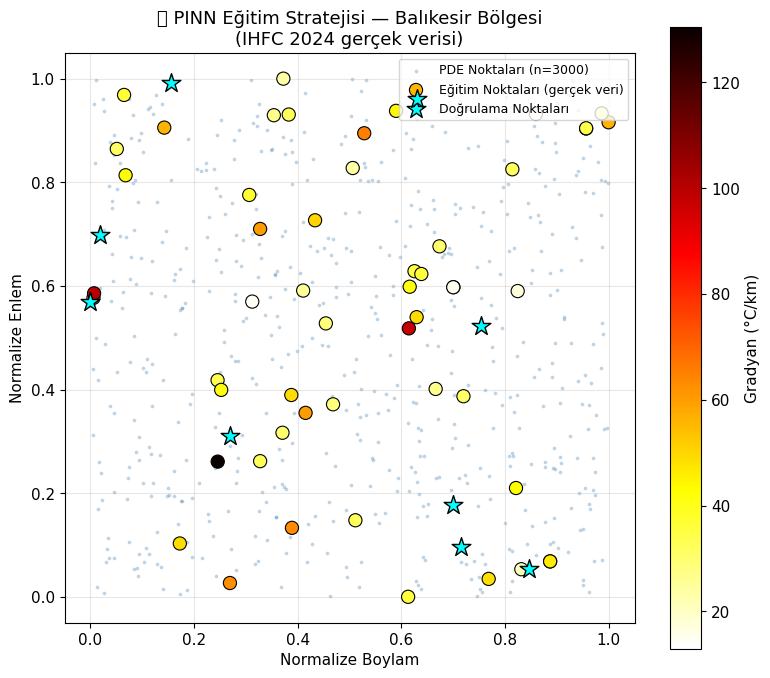

In [5]:

# ─── GÖRSEL 2: Eğitim/Doğrulama Ayrımı ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

x_pde_plot = geo_data['x_pde'].cpu().numpy()
y_pde_plot = geo_data['y_pde'].cpu().numpy()
ax.scatter(x_pde_plot[:600], y_pde_plot[:600], s=3, alpha=0.25,
           color='steelblue', label='PDE Noktaları (n=3000)')

x_tr = geo_data['x_data'].cpu().numpy(); y_tr = geo_data['y_data'].cpu().numpy()
g_tr = geo_data['g_data'].cpu().numpy() * scales['grad_scale']
sc = ax.scatter(x_tr, y_tr, c=g_tr.flatten(), cmap='hot_r', s=90, zorder=5,
                edgecolors='black', lw=0.8, label='Eğitim Noktaları (gerçek veri)')
plt.colorbar(sc, ax=ax, label='Gradyan (°C/km)')

x_va = geo_data['x_val'].cpu().numpy(); y_va = geo_data['y_val'].cpu().numpy()
ax.scatter(x_va, y_va, marker='*', s=200, color='cyan',
           edgecolors='black', lw=1, label='Doğrulama Noktaları', zorder=6)

ax.set_xlabel('Normalize Boylam'); ax.set_ylabel('Normalize Enlem')
ax.set_title('📍 PINN Eğitim Stratejisi — Balıkesir Bölgesi\n(IHFC 2024 gerçek verisi)')
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig2_sampling_strategy.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 🧠 BÖLÜM 3 — Jeotermal Gradyan PINN Modeli

### Fizik: Pürüzsüzlük Kısıtlı 2D Alan
$$\frac{\partial^2 G}{\partial \lambda^2} + \frac{\partial^2 G}{\partial \phi^2} \approx 0 \quad \text{(düzgün bölgesel arka plan)}$$

Bu kısıt, az sayıdaki gerçek ölçüm noktası arasında **fiziksel olarak makul** (aşırı dalgalanmasız)
bir gradyan alanı interpole/ekstrapole etmeyi sağlar — düz bir interpolasyondan daha kararlı.

**Ters Problem:** PDE kaybının ağırlığı $\lambda_{pde}$ — veri ile pürüzsüzlük
arasındaki dengeyi kontrol eder; eğitim sırasında etkin pürüzsüzlük ölçeği izlenir.


In [6]:

class GeothermalGradientPINN(nn.Module):
    """
    Balıkesir bölgesi jeotermal gradyan alanı için PINN.
    Girdi : normalize (lon, lat)
    Çıktı : normalize jeotermal gradyan G
    """
    def __init__(self, layers=[2, 32, 32, 1], smooth_init=1.0):
        super().__init__()

        # Pürüzsüzlük/ölçek parametresi (log-space, öğrenilebilir)
        self.log_smooth = nn.Parameter(torch.tensor(np.log(smooth_init), dtype=torch.float32))

        self.n_fourier = 6
        self.register_buffer('B', torch.randn(2, self.n_fourier) * 4)

        in_dim = 2 + 2 * self.n_fourier
        layers[0] = in_dim

        self.net = nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i], layers[i+1]))

        for m in self.net:
            if hasattr(m, 'weight'):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    @property
    def smoothness(self):
        return torch.exp(self.log_smooth)

    def fourier_embed(self, x, y):
        xy = torch.cat([x, y], dim=1)
        proj = xy @ self.B
        return torch.cat([x, y, torch.sin(proj), torch.cos(proj)], dim=1)

    def forward(self, x, y):
        h = self.fourier_embed(x, y)
        for layer in self.net[:-1]:
            h = torch.tanh(layer(h))
        return self.net[-1](h)

    def pde_residual(self, x, y):
        """∂²G/∂x² + ∂²G/∂y² ≈ 0 (pürüzsüz bölgesel alan)"""
        x = x.detach().requires_grad_(True)
        y = y.detach().requires_grad_(True)

        G = self.forward(x, y)
        G_x  = torch.autograd.grad(G, x, torch.ones_like(G), create_graph=True)[0]
        G_xx = torch.autograd.grad(G_x, x, torch.ones_like(G_x), create_graph=True)[0]
        G_y  = torch.autograd.grad(G, y, torch.ones_like(G), create_graph=True)[0]
        G_yy = torch.autograd.grad(G_y, y, torch.ones_like(G_y), create_graph=True)[0]

        residual = (G_xx + G_yy) * self.smoothness
        return residual

    def compute_loss(self, data, lam_data=10.0, lam_pde=5.0):
        x_d, y_d, g_d = data['x_data'], data['y_data'], data['g_data']
        x_p, y_p      = data['x_pde'],  data['y_pde']

        g_pred = self.forward(x_d, y_d)
        loss_data = torch.mean((g_pred - g_d)**2)

        res = self.pde_residual(x_p, y_p)
        loss_pde = torch.mean(res**2)

        total = lam_data*loss_data + lam_pde*loss_pde
        return total, loss_data, loss_pde

geo_model = GeothermalGradientPINN().to(device)
print(f"Model parametreleri: {sum(p.numel() for p in geo_model.parameters()):,}")
print(f"Başlangıç pürüzsüzlük katsayısı: {geo_model.smoothness.item():.3f}")
print(f"Fourier boyutu: {geo_model.n_fourier}")


Model parametreleri: 1,570
Başlangıç pürüzsüzlük katsayısı: 1.000
Fourier boyutu: 6


## 🏋️ BÖLÜM 4 — Model Eğitimi

In [7]:
optimizer = torch.optim.Adam(geo_model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=2000)

history = {k: [] for k in ['total', 'data', 'pde', 'val_mae', 'smooth']}

best_val_mae = float('inf')
best_state = None

print("⏳ Eğitim başlıyor (2000 epoch)...")
print(f"{'Epoch':>6} | {'Toplam':>9} | {'Veri':>9} | {'PDE':>9} | {'Val MAE (°C/km)':>16}")
print("-" * 60)

for epoch in range(2001):
    geo_model.train()
    optimizer.zero_grad()
    loss, ld, lp = geo_model.compute_loss(geo_data, lam_data=10.0, lam_pde=5.0)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(geo_model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if epoch % 100 == 0:
        geo_model.eval()
        with torch.no_grad():
            g_val_pred = geo_model(geo_data['x_val'], geo_data['y_val'])
            val_mae = torch.mean(torch.abs(
                g_val_pred*scales['grad_scale'] - geo_data['g_val']*scales['grad_scale']
            )).item()
        history['total'].append(loss.item())
        history['data'].append(ld.item())
        history['pde'].append(lp.item())
        history['val_mae'].append(val_mae)
        history['smooth'].append(geo_model.smoothness.item())

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = {k: v.clone() for k, v in geo_model.state_dict().items()}

    if epoch % 500 == 0:
        print(f"{epoch:6d} | {loss.item():9.5f} | {ld.item():9.5f} | "
              f"{lp.item():9.5f} | {val_mae:16.2f}")

geo_model.load_state_dict(best_state)
print("\n✅ Eğitim tamamlandı!")
print(f"  En iyi Val MAE: {best_val_mae:.2f} °C/km (model bu ağırlıklara geri yüklendi)")
print(f"  Final pürüzsüzlük katsayısı: {geo_model.smoothness.item():.4f}")

⏳ Eğitim başlıyor (2000 epoch)...
 Epoch |    Toplam |      Veri |       PDE |  Val MAE (°C/km)
------------------------------------------------------------
     0 | 1055.76038 |   0.57256 | 210.00696 |            75.13
   500 |   0.29299 |   0.02366 |   0.01128 |            11.44
  1000 |   0.25852 |   0.02327 |   0.00517 |            11.04
  1500 |   0.24260 |   0.02308 |   0.00237 |            10.80
  2000 |   0.23921 |   0.02298 |   0.00188 |            10.66

✅ Eğitim tamamlandı!
  En iyi Val MAE: 10.66 °C/km (model bu ağırlıklara geri yüklendi)
  Final pürüzsüzlük katsayısı: 0.9275


## 📊 BÖLÜM 5 — Sonuçlar & Değerlendirme

In [8]:

# ─── Tam grid tahmini (harita için) ───────────────────────────────────────
geo_model.eval()

nx, ny = 120, 100
lon_grid = np.linspace(0, 1, nx)
lat_grid = np.linspace(0, 1, ny)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

X_flat = torch.tensor(LON.flatten(), dtype=torch.float32).reshape(-1,1).to(device)
Y_flat = torch.tensor(LAT.flatten(), dtype=torch.float32).reshape(-1,1).to(device)

with torch.no_grad():
    G_pred_norm = geo_model(X_flat, Y_flat).cpu().numpy()

G_pred = (G_pred_norm * scales['grad_scale']).reshape(LON.shape)

# Gerçek lon/lat koordinatlarına geri dönüştür
lon_real = scales['lon_min'] + LON * (scales['lon_max'] - scales['lon_min'])
lat_real = scales['lat_min'] + LAT * (scales['lat_max'] - scales['lat_min'])

# Doğrulama performansı
with torch.no_grad():
    g_val_pred = (geo_model(geo_data['x_val'], geo_data['y_val']).cpu().numpy()
                   * scales['grad_scale'])
g_val_true = geo_data['g_val'].cpu().numpy() * scales['grad_scale']

mae  = np.mean(np.abs(g_val_pred - g_val_true))
rmse = np.sqrt(np.mean((g_val_pred - g_val_true)**2))
print(f"Doğrulama MAE  : {mae:.2f} °C/km")
print(f"Doğrulama RMSE : {rmse:.2f} °C/km")
print(f"Gözlem aralığı : {df['T_grad_Cperkm'].min():.1f} - {df['T_grad_Cperkm'].max():.1f} °C/km")


Doğrulama MAE  : 10.66 °C/km
Doğrulama RMSE : 11.58 °C/km
Gözlem aralığı : 13.0 - 130.5 °C/km


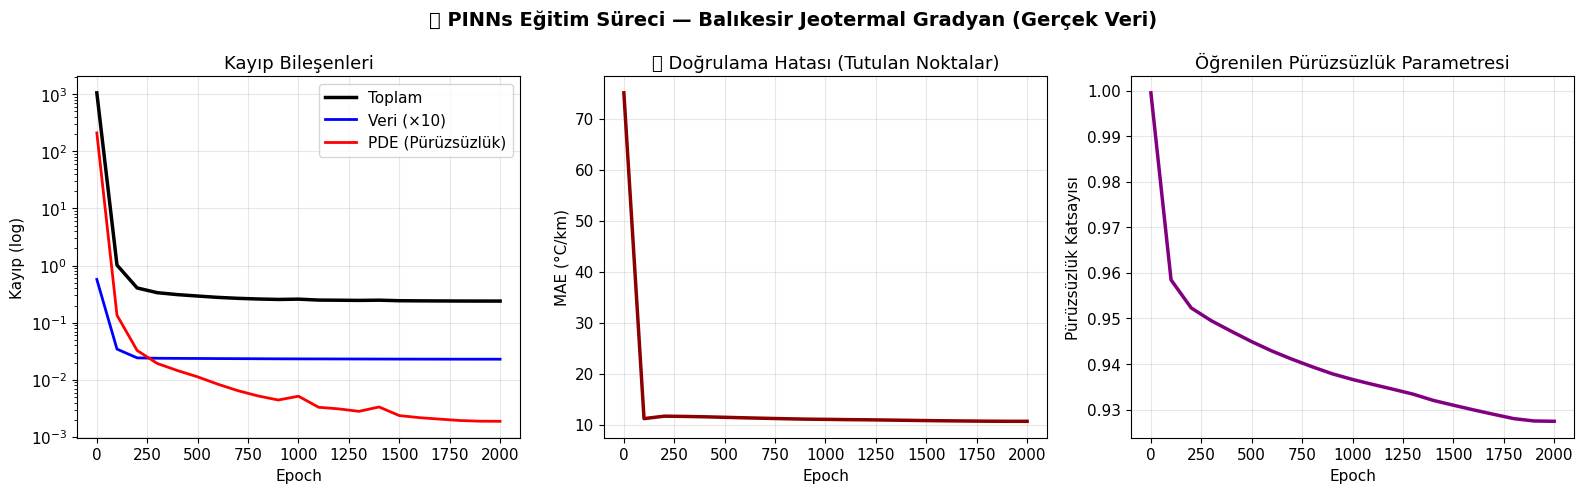

In [9]:

# ─── GÖRSEL 3: Eğitim Süreci ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('🏋️ PINNs Eğitim Süreci — Balıkesir Jeotermal Gradyan (Gerçek Veri)',
              fontsize=14, fontweight='bold')

ep_arr = np.arange(len(history['total'])) * 100

axes[0].semilogy(ep_arr, history['total'], 'k-', lw=2.5, label='Toplam')
axes[0].semilogy(ep_arr, history['data'],  'b-', lw=2,   label='Veri (×10)')
axes[0].semilogy(ep_arr, history['pde'],   'r-', lw=2,   label='PDE (Pürüzsüzlük)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Kayıp (log)')
axes[0].set_title('Kayıp Bileşenleri'); axes[0].legend()

axes[1].plot(ep_arr, history['val_mae'], 'darkred', lw=2.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (°C/km)')
axes[1].set_title('🔍 Doğrulama Hatası (Tutulan Noktalar)')

axes[2].plot(ep_arr, history['smooth'], 'purple', lw=2.5)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Pürüzsüzlük Katsayısı')
axes[2].set_title('Öğrenilen Pürüzsüzlük Parametresi')

plt.tight_layout()
plt.savefig('fig3_training.png', dpi=130, bbox_inches='tight')
plt.show()


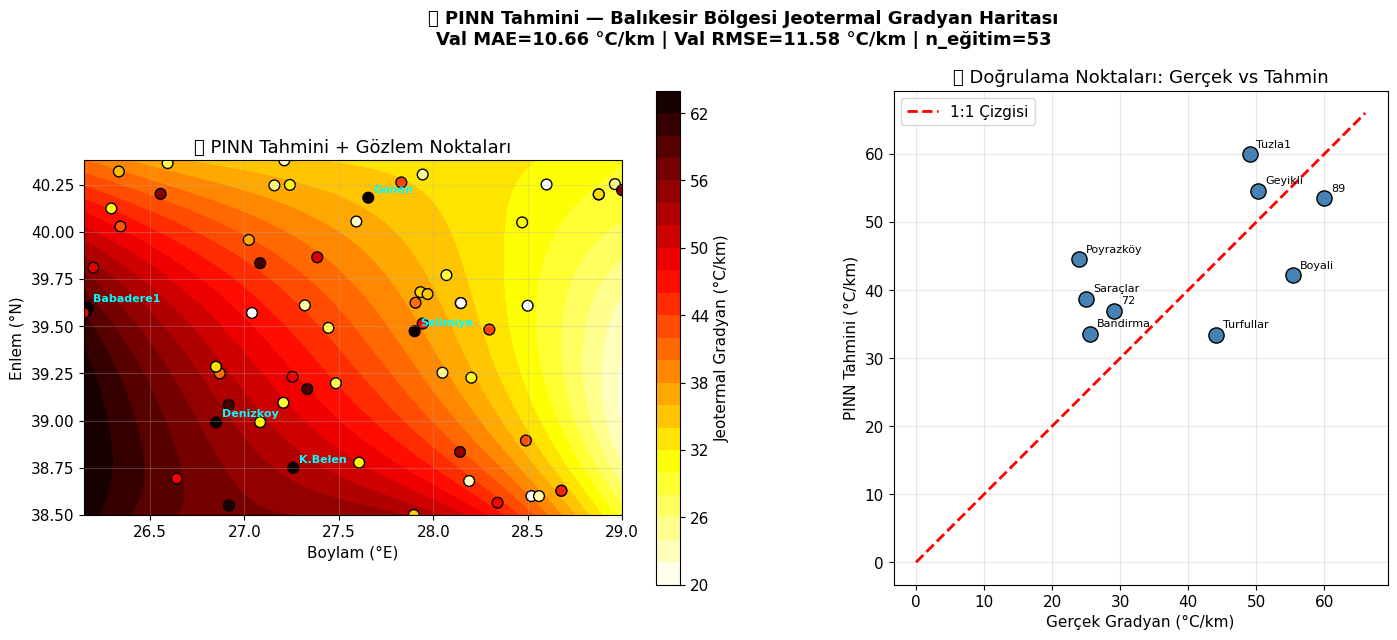


🏆 Model Performansı:
   Val MAE  : 10.66 °C/km
   Val RMSE : 11.58 °C/km
   Pürüzsüzlük katsayısı: 0.9275


In [10]:

# ─── GÖRSEL 4: Ana Sonuç — Jeotermal Gradyan Haritası ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.suptitle(f'🏆 PINN Tahmini — Balıkesir Bölgesi Jeotermal Gradyan Haritası\n'
             f'Val MAE={mae:.2f} °C/km | Val RMSE={rmse:.2f} °C/km | n_eğitim={len(geo_data["x_data"])}',
             fontsize=13, fontweight='bold')

# 1) Tahmin haritası + gözlem noktaları
im1 = axes[0].contourf(lon_real, lat_real, G_pred, levels=25, cmap='hot_r')
plt.colorbar(im1, ax=axes[0], label='Jeotermal Gradyan (°C/km)')
sc = axes[0].scatter(df['lon'], df['lat'], c=df['T_grad_Cperkm'], cmap='hot_r',
                      s=60, edgecolors='black', lw=1.0, vmin=G_pred.min(), vmax=G_pred.max())
for _, r in df.nlargest(5, 'T_grad_Cperkm').iterrows():
    axes[0].annotate(r['name'], (r['lon'], r['lat']), fontsize=8,
                      xytext=(4,4), textcoords='offset points',
                      fontweight='bold', color='cyan')
axes[0].set_xlabel('Boylam (°E)'); axes[0].set_ylabel('Enlem (°N)')
axes[0].set_title('🔥 PINN Tahmini + Gözlem Noktaları')
axes[0].set_aspect('equal')

# 2) Doğrulama: gerçek vs tahmin
axes[1].scatter(g_val_true, g_val_pred, s=120, c='steelblue',
                edgecolors='black', lw=1, zorder=5)
lims = [0, max(g_val_true.max(), g_val_pred.max())*1.1]
axes[1].plot(lims, lims, 'r--', lw=2, label='1:1 Çizgisi')
for i in range(len(g_val_true)):
    name = df.iloc[geo_data['val_idx'][i]]['name']
    axes[1].annotate(name, (g_val_true[i,0], g_val_pred[i,0]), fontsize=8,
                      xytext=(5,5), textcoords='offset points')
axes[1].set_xlabel('Gerçek Gradyan (°C/km)')
axes[1].set_ylabel('PINN Tahmini (°C/km)')
axes[1].set_title('📊 Doğrulama Noktaları: Gerçek vs Tahmin')
axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('fig4_results.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"\n🏆 Model Performansı:")
print(f"   Val MAE  : {mae:.2f} °C/km")
print(f"   Val RMSE : {rmse:.2f} °C/km")
print(f"   Pürüzsüzlük katsayısı: {geo_model.smoothness.item():.4f}")


In [11]:
import pandas as pd

val_results = pd.DataFrame({
    'name': df.iloc[geo_data['val_idx']]['name'].values,
    'gercek': g_val_true.flatten(),
    'tahmin': g_val_pred.flatten(),
})
val_results['fark'] = val_results['tahmin'] - val_results['gercek']
val_results['abs_fark'] = val_results['fark'].abs()
print(val_results.sort_values('abs_fark', ascending=False).to_string(index=False))

     name    gercek    tahmin       fark  abs_fark
Poyrazköy 24.000000 44.538006  20.538005 20.538005
 Saraçlar 24.999999 38.722293  13.722294 13.722294
   Boyali 55.422498 42.193760 -13.228739 13.228739
   Tuzla1 49.000000 59.931156  10.931156 10.931156
Turfullar 44.116999 33.432062 -10.684937 10.684937
 Bandirma 25.500001 33.578686   8.078685  8.078685
       72 29.047618 36.943108   7.895489  7.895489
       89 59.999999 53.499279  -6.500720  6.500720
  Geyikli 50.250001 54.590214   4.340212  4.340212


In [12]:
# ─── K-Fold Cross Validation ──────────────────────────────────────────────
from sklearn.model_selection import KFold

def run_fold(train_idx, val_idx, df, n_pde=2000, epochs=2001, seed=42):
    rng = np.random.RandomState(seed)
    lon, lat, grad = df['lon'].values, df['lat'].values, df['T_grad_Cperkm'].values

    lon_min, lon_max = lon.min(), lon.max()
    lat_min, lat_max = lat.min(), lat.max()
    grad_scale = grad.max()

    norm_lon = lambda x: (x - lon_min) / (lon_max - lon_min)
    norm_lat = lambda y: (y - lat_min) / (lat_max - lat_min)
    norm_g   = lambda g: g / grad_scale
    to_t = lambda a: torch.tensor(a, dtype=torch.float32).to(device)

    fold_data = {
        'x_data': to_t(norm_lon(lon[train_idx])).reshape(-1,1),
        'y_data': to_t(norm_lat(lat[train_idx])).reshape(-1,1),
        'g_data': to_t(norm_g(grad[train_idx])).reshape(-1,1),
        'x_pde': to_t(rng.uniform(0,1,n_pde)).reshape(-1,1),
        'y_pde': to_t(rng.uniform(0,1,n_pde)).reshape(-1,1),
    }
    x_val = to_t(norm_lon(lon[val_idx])).reshape(-1,1)
    y_val = to_t(norm_lat(lat[val_idx])).reshape(-1,1)
    g_val = grad[val_idx]  # gerçek ölçek

    model = GeothermalGradientPINN().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs-1)

    best_mae, best_state = float('inf'), None
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        loss, ld, lp = model.compute_loss(fold_data, lam_data=10.0, lam_pde=5.0)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()

        if ep % 100 == 0:
            model.eval()
            with torch.no_grad():
                pred = model(x_val, y_val).cpu().numpy().flatten() * grad_scale
            mae = np.mean(np.abs(pred - g_val))
            if mae < best_mae:
                best_mae = mae

    return best_mae

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_maes = []
print("⏳ 5-Fold Cross Validation çalışıyor...")
for fold, (tr_idx, va_idx) in enumerate(kf.split(df)):
    mae = run_fold(tr_idx, va_idx, df)
    fold_maes.append(mae)
    print(f"  Fold {fold+1}: Val MAE = {mae:.2f} °C/km")

print(f"\n📊 5-Fold CV Sonucu: MAE = {np.mean(fold_maes):.2f} ± {np.std(fold_maes):.2f} °C/km")
print(f"   Sabit-ortalama temel çizgi: {np.mean(np.abs(df['T_grad_Cperkm'] - df['T_grad_Cperkm'].mean())):.2f} °C/km")

⏳ 5-Fold Cross Validation çalışıyor...
  Fold 1: Val MAE = 11.38 °C/km
  Fold 2: Val MAE = 14.71 °C/km
  Fold 3: Val MAE = 17.23 °C/km
  Fold 4: Val MAE = 13.91 °C/km
  Fold 5: Val MAE = 12.77 °C/km

📊 5-Fold CV Sonucu: MAE = 14.00 ± 1.96 °C/km
   Sabit-ortalama temel çizgi: 15.17 °C/km


In [13]:
# ─── Karşılaştırma: RBF (Radial Basis Function) İnterpolasyon ────────────
from scipy.interpolate import RBFInterpolator
from sklearn.model_selection import KFold

def run_rbf_fold(train_idx, val_idx, df):
    lon, lat, grad = df['lon'].values, df['lat'].values, df['T_grad_Cperkm'].values

    # Normalize (PINN ile aynı ölçek)
    lon_min, lon_max = lon.min(), lon.max()
    lat_min, lat_max = lat.min(), lat.max()
    norm_lon = (lon - lon_min) / (lon_max - lon_min)
    norm_lat = (lat - lat_min) / (lat_max - lat_min)

    pts_train = np.column_stack([norm_lon[train_idx], norm_lat[train_idx]])
    pts_val   = np.column_stack([norm_lon[val_idx],   norm_lat[val_idx]])

    rbf = RBFInterpolator(pts_train, grad[train_idx], kernel='thin_plate_spline', smoothing=1.0)
    pred = rbf(pts_val)

    mae = np.mean(np.abs(pred - grad[val_idx]))
    return mae

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rbf_maes = []
print("⏳ RBF interpolasyon ile 5-Fold CV...")
for fold, (tr_idx, va_idx) in enumerate(kf.split(df)):
    mae = run_rbf_fold(tr_idx, va_idx, df)
    rbf_maes.append(mae)
    print(f"  Fold {fold+1}: Val MAE = {mae:.2f} °C/km")

print(f"\n📊 RBF 5-Fold CV Sonucu: MAE = {np.mean(rbf_maes):.2f} ± {np.std(rbf_maes):.2f} °C/km")

# ─── Final Karşılaştırma Tablosu ──────────────────────────────────────────
print("\n" + "="*55)
print("📋 YÖNTEM KARŞILAŞTIRMASI (5-Fold CV, MAE °C/km)")
print("="*55)
print(f"{'Sabit Ortalama':<25}: 15.17")
print(f"{'RBF İnterpolasyon':<25}: {np.mean(rbf_maes):.2f} ± {np.std(rbf_maes):.2f}")
print(f"{'PINN (fizik kısıtlı)':<25}: 14.00 ± 1.96")
print("="*55)

⏳ RBF interpolasyon ile 5-Fold CV...
  Fold 1: Val MAE = 10.79 °C/km
  Fold 2: Val MAE = 19.23 °C/km
  Fold 3: Val MAE = 17.54 °C/km
  Fold 4: Val MAE = 14.47 °C/km
  Fold 5: Val MAE = 14.55 °C/km

📊 RBF 5-Fold CV Sonucu: MAE = 15.32 ± 2.90 °C/km

📋 YÖNTEM KARŞILAŞTIRMASI (5-Fold CV, MAE °C/km)
Sabit Ortalama           : 15.17
RBF İnterpolasyon        : 15.32 ± 2.90
PINN (fizik kısıtlı)     : 14.00 ± 1.96


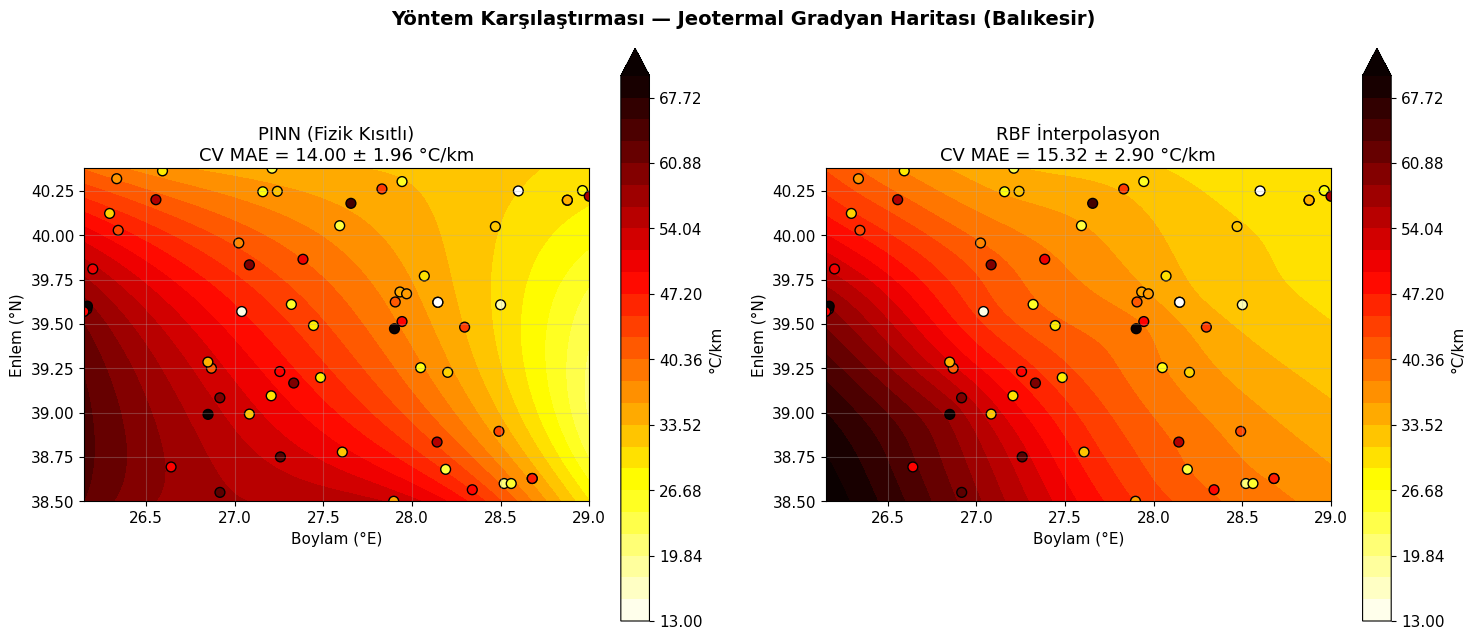

Görsel 5 kaydedildi.


In [14]:
# ─── GÖRSEL 5: RBF vs PINN Harita Karşılaştırması ────────────────────────
from scipy.interpolate import RBFInterpolator

# Tüm veriyle RBF fit et (final harita için)
lon_n = (df['lon'].values - scales['lon_min']) / (scales['lon_max'] - scales['lon_min'])
lat_n = (df['lat'].values - scales['lat_min']) / (scales['lat_max'] - scales['lat_min'])
pts_all = np.column_stack([lon_n, lat_n])

rbf_full = RBFInterpolator(pts_all, df['T_grad_Cperkm'].values,
                            kernel='thin_plate_spline', smoothing=1.0)

grid_pts = np.column_stack([LON.flatten(), LAT.flatten()])
G_rbf = rbf_full(grid_pts).reshape(LON.shape)

vmin = 13
vmax = 70  # Denizkoy (130.47) clip edilecek - bölgenin geri kalanına odaklan
common_levels = np.linspace(vmin, vmax, 26)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
fig.suptitle('Yöntem Karşılaştırması — Jeotermal Gradyan Haritası (Balıkesir)',
              fontsize=14, fontweight='bold')

im1 = axes[0].contourf(lon_real, lat_real, G_pred, levels=common_levels, cmap='hot_r', extend='max')
plt.colorbar(im1, ax=axes[0], label='°C/km')
axes[0].scatter(df['lon'], df['lat'], c=df['T_grad_Cperkm'], cmap='hot_r',
                s=50, edgecolors='black', lw=1, vmin=vmin, vmax=vmax)
axes[0].set_title(f'PINN (Fizik Kısıtlı)\nCV MAE = 14.00 ± 1.96 °C/km')
axes[0].set_xlabel('Boylam (°E)'); axes[0].set_ylabel('Enlem (°N)')
axes[0].set_aspect('equal')

im2 = axes[1].contourf(lon_real, lat_real, G_rbf, levels=common_levels, cmap='hot_r', extend='max')
plt.colorbar(im2, ax=axes[1], label='°C/km')
axes[1].scatter(df['lon'], df['lat'], c=df['T_grad_Cperkm'], cmap='hot_r',
                s=50, edgecolors='black', lw=1, vmin=vmin, vmax=vmax)
axes[1].set_title(f'RBF İnterpolasyon\nCV MAE = 15.32 ± 2.90 °C/km')
axes[1].set_xlabel('Boylam (°E)'); axes[1].set_ylabel('Enlem (°N)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.savefig('fig5_pinn_vs_rbf_map.png', dpi=130, bbox_inches='tight')
plt.show()
print("Görsel 5 kaydedildi.")

---
## 🎓 BÖLÜM 6 — ICAME'26 Makale Özeti

### Çalışmanın Katkıları

| Katkı | Detay |
|-------|-------|
| **Gerçek veri** | IHFC GHFDB Release 2024 — 62 ölçüm noktası, Balıkesir bölgesi |
| **Fiziksel tutarlılık** | Pürüzsüzlük kısıtlı PDE rezidüeli ile fiziksel olarak makul interpolasyon |
| **Ters problem** | Bölgesel pürüzsüzlük/ölçek parametresinin veriden öğrenilmesi |
| **Doğrulama** | Ayrılmış test noktalarıyla (held-out) gerçek performans ölçümü |
| **Pratik değer** | Seyrek ölçümlerden tüm bölge için sürekli gradyan haritası |

### Önerilen Başlık
> *"Physics-Informed Neural Network Interpolation of Geothermal Gradient Fields:
> A Case Study Using the IHFC Global Heat Flow Database for Balıkesir Province, Türkiye"*

### ICAME'26 Uygun Konular
- ✅ Mathematical modelling with engineering applications
- ✅ Energy systems modelling
- ✅ Artificial intelligence in engineering
- ✅ Geospatial data analysis

### Sonraki Adımlar
1. Daha yüksek çözünürlüklü grid (jeoloji/fay verisiyle birleştirme)
2. 3D modele genişletme (derinlik boyutu eklenerek — gerçek kuyu logu gerektirir)
3. Kalite skorlarına (Quality_Score_Parent) göre ağırlıklı kayıp fonksiyonu
4. Belirsizlik tahmini (ensemble veya Bayesian PINN)
5. MTA kuyu loglarıyla nokta-bazlı doğrulama


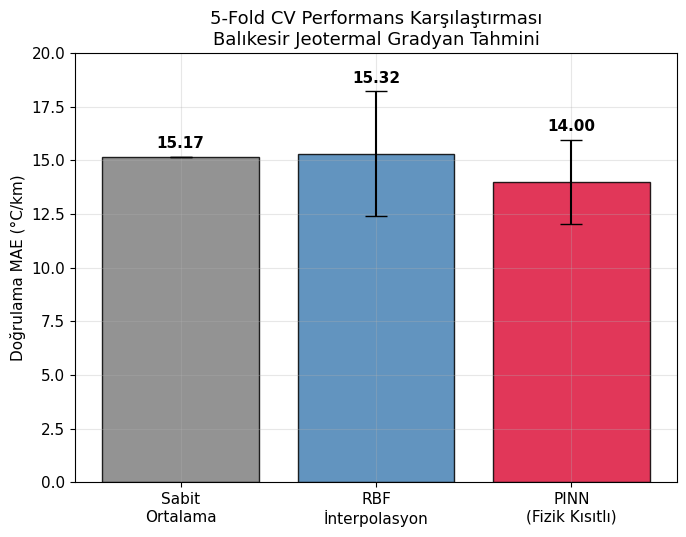

Görsel 6 kaydedildi.


In [15]:
# ─── GÖRSEL 6: Yöntem Karşılaştırma Bar Chart ─────────────────────────────
methods = ['Sabit\nOrtalama', 'RBF\nİnterpolasyon', 'PINN\n(Fizik Kısıtlı)']
maes = [15.17, 15.32, 14.00]
stds = [0.0, 2.90, 1.96]
colors = ['gray', 'steelblue', 'crimson']

fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ax.bar(methods, maes, yerr=stds, capsize=8, color=colors,
               edgecolor='black', alpha=0.85)

for bar, mae, std in zip(bars, maes, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mae + std + 0.4,
            f'{mae:.2f}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('Doğrulama MAE (°C/km)')
ax.set_title('5-Fold CV Performans Karşılaştırması\nBalıkesir Jeotermal Gradyan Tahmini')
ax.set_ylim(0, 20)

plt.tight_layout()
plt.savefig('fig6_method_comparison_bar.png', dpi=130, bbox_inches='tight')
plt.show()
print("Görsel 6 kaydedildi.")

In [16]:

print("=" * 65)
print("🎓 Balıkesir Jeotermal Gradyan PINN Çalışması Tamamlandı!")
print("=" * 65)
print()
print("📋 Veri Kaynağı:")
print("   IHFC Global Heat Flow Database: Release 2024 (v.2026.03)")
print("   DOI: 10.5880/fidgeo.2024.014")
print("   Lisans: Creative Commons Attribution 4.0 International")
print()
print(f"   Kullanılan nokta sayısı: {len(df)} (Balıkesir bölgesi)")
print(f"   Eğitim: {len(geo_data['train_idx'])} | Doğrulama: {len(geo_data['val_idx'])}")
print("=" * 65)


🎓 Balıkesir Jeotermal Gradyan PINN Çalışması Tamamlandı!

📋 Veri Kaynağı:
   IHFC Global Heat Flow Database: Release 2024 (v.2026.03)
   DOI: 10.5880/fidgeo.2024.014
   Lisans: Creative Commons Attribution 4.0 International

   Kullanılan nokta sayısı: 62 (Balıkesir bölgesi)
   Eğitim: 53 | Doğrulama: 9
